# Results

This notebook serves as an entrypoint to the codebase, defining the curriculum of increasing difficulty and displaying the results of the thre training sequences.

## Curriculum definition
The curriculum is based on the frequency of letters in the dataset, with a penalty for duplicate letters. The words are sorted from easy to hard and divided into three datasets: easy, medium, and hard. Each dataset is saved as a separate text file for use in training the agents.

In [1]:
from collections import Counter

def create_curriculum_datasets(input_filepath="src/data/answers.txt"):
    # We just verify that we only have 5-letter words
    with open(input_filepath, 'r', encoding='utf-8') as f:
        words = [word.lower() for line in f for word in line.strip().split() if len(word) == 5 and word.isalpha()]

    if not words:
        print("Error : No word found.")
        return

    # Want to find the frequency of every letter in this specific dataset
    all_letters = "".join(words)
    letter_counts = Counter(all_letters)
    total_letters = sum(letter_counts.values())
    letter_freqs = {char: count / total_letters for char, count in letter_counts.items()}

    # Let's define word difficulty
    def get_word_score(word):
        unique_letters = set(word) # Keep only unique letters from the word

        freq_score = sum(letter_freqs[char] for char in unique_letters)

        # We want to penalize duplicates - see the report for further details
        duplicates = len(word) - len(unique_letters)
        penalty = duplicates * 0.15

        return freq_score - penalty

    scored_words = [(word, get_word_score(word)) for word in words]

    # Here we implement classic Curriculum learning, so we sort from easy to hard
    scored_words.sort(key=lambda x: x[1], reverse=True)
    sorted_words = [word for word, score in scored_words]

    # Let's divide the dataset into 3 parts to create 3 levels of difficulty
    n = len(sorted_words)
    easy = sorted_words[:n//3]
    medium = sorted_words[n//3:2*n//3]
    hard = sorted_words[2*n//3:]

    datasets = {
        "src/data/dataset_1_easy.txt": easy,
        "src/data/dataset_2_medium.txt": medium,
        "src/data/dataset_3_hard.txt": hard
    }

    for filename, dataset in datasets.items():
        with open(filename, 'w', encoding='utf-8') as f:
            for w in dataset:
                f.write(w + '\n')

    print(f"Done! Datasets created :")
    print(f"- {len(easy)} easy words (ex: {', '.join(easy[:5])})")
    print(f"- {len(medium)} medium words (ex: {', '.join(medium[:5])})")
    print(f"- {len(hard)} hard words (ex: {', '.join(hard[-5:])})")

In [2]:
create_curriculum_datasets()

Done! Datasets created :
- 771 easy words (ex: alert, alter, later, arose, irate)
- 772 medium words (ex: evict, rhyme, stork, sloth, fetid)
- 772 hard words (ex: civic, puppy, vivid, mummy, mamma)


## Plots

Here we plot the results of the three training sequences: Naive (without CL), Warmup (randomized curriculum of increasing size) and Curriculum (curriculum of increasing size and difficulty). We compare the rewards, win rates, and number of attempts of each agent to evaluate the impact of curriculum learning on the agent's performance. The plots are smoothed using a rolling average with a window size of 1000 episodes. If the historical logs are not found, the training sequences will be executed to generate the necessary data for plotting. Otherwise, the existing logs will be loaded and plotted directly.

In [3]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

try:
    from naive import train_naive
    from warmup import train_with_warmup
    from curriculum import train_with_curriculum
    print("Execution scripts successfully imported.")
except ImportError:
    print("Import Error: Verify scripts are in the working directory.")

REQUIRED_LOGS = [
    'results/naive/reward_history.json',
    'results/naive/win_history.json',
    'results/naive/attempt_history.json',
    'results/warmup/reward_history.json',
    'results/warmup/win_history.json',
    'results/warmup/attempt_history.json',
    'results/curriculum/reward_history.json',
    'results/curriculum/win_history.json',
    'results/curriculum/attempt_history.json',
]

if any(not os.path.exists(f) for f in REQUIRED_LOGS):
    print("Logs missing. Executing training sequences...")
    train_naive()
    train_with_warmup()
    train_with_curriculum()
    print("Data logging complete.")
else:
    print("All historical logs detected. Skipping training sequence.")

Execution scripts successfully imported.
All historical logs detected. Skipping training sequence.


In [4]:
def load_log(filepath):
    with open(filepath, 'r') as f:
        return np.array(json.load(f), dtype=np.float32)

output_dir = 'results/plots'
os.makedirs(output_dir, exist_ok=True)

reward_m1 = load_log('results/naive/reward_history.json')
reward_m2 = load_log('results/warmup/reward_history.json')
reward_m3 = load_log('results/curriculum/reward_history.json')

win_m1 = load_log('results/naive/win_history.json')
win_m2 = load_log('results/warmup/win_history.json')
win_m3 = load_log('results/curriculum/win_history.json')

attempt_m1 = load_log('results/naive/attempt_history.json')
attempt_m2 = load_log('results/warmup/attempt_history.json')
attempt_m3 = load_log('results/curriculum/attempt_history.json')

def plot_metrics(data1, data2, data3, title, ylabel, filename, window=1000):
    plt.subplots(figsize=(10, 5))
    
    kernel = np.ones(window, dtype=np.float32) / window
    smoothed1 = np.convolve(data1, kernel, mode='valid')
    smoothed2 = np.convolve(data2, kernel, mode='valid')
    smoothed3 = np.convolve(data3, kernel, mode='valid')
    plt.plot(range(window, window+len(smoothed1)), smoothed1, label='No curriculum')
    plt.plot(range(window, window+len(smoothed2)), smoothed2, label='Randomized curriculum')
    plt.plot(range(window, window+len(smoothed3)), smoothed3, label='Curriculum of increasing difficulty')
    plt.axvline([2000.5], color='C3', label = 'Increase to 100 words')
    plt.axvline([20000.5], color ='C4', label = 'Increase to 500 words')
    plt.axvline([40000.5], color='C5', label = 'Full vocabulary')
    plt.title(title)
    plt.xlabel('Episodes')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

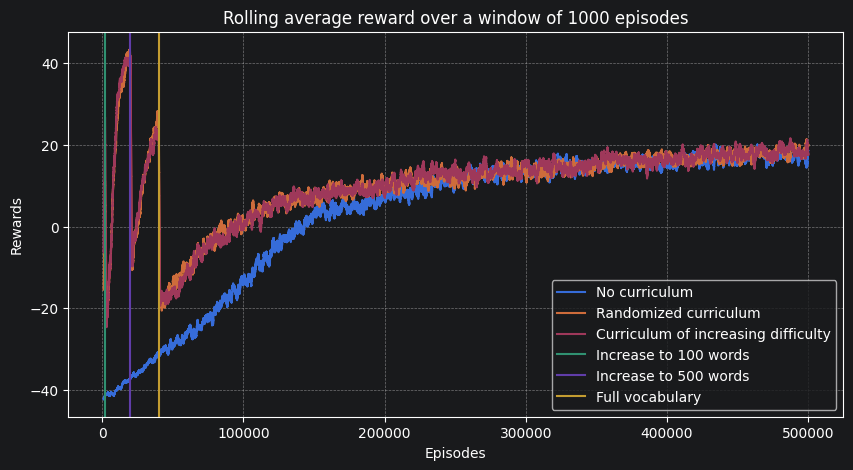

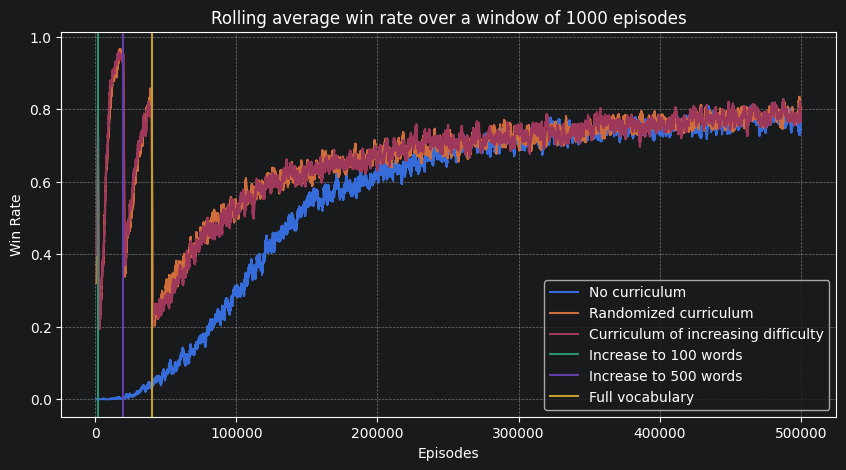

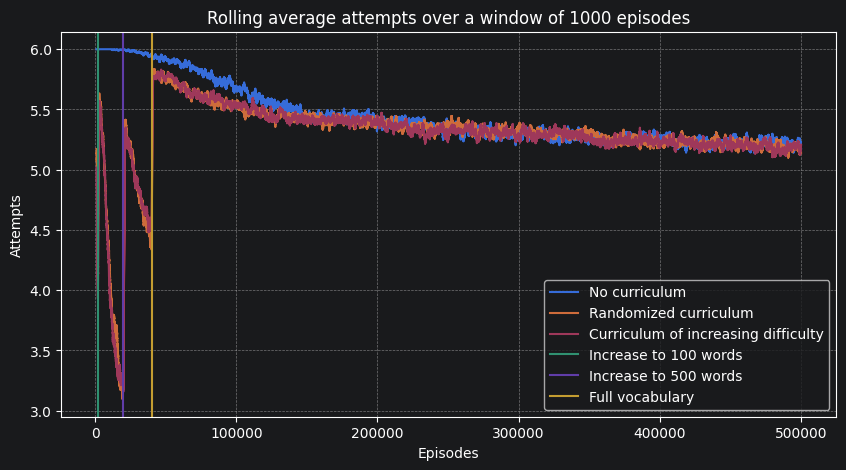

In [5]:
plot_metrics(reward_m1, reward_m2, reward_m3, 'Rolling average reward over a window of 1000 episodes', 'Rewards', 'all_comparison_reward.png')
plot_metrics(win_m1, win_m2, win_m3, 'Rolling average win rate over a window of 1000 episodes', 'Win Rate', 'all_comparison_winrate.png')
plot_metrics(attempt_m1, attempt_m2, attempt_m3, 'Rolling average attempts over a window of 1000 episodes', 'Attempts', 'all_comparison_attempts.png')